## Imports

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr, linregress

## Loading Datasets and Investigating Solvent Distribution

In [3]:
# creating a variable to store the absolute .csv file path for the full Deep4Chem dataset
d4c_path = r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_chemprop/Deep4Chem_chemprop/d4c_ext_coef_all_data.csv'
# reading in the dataset as stored in the path variable
d4c_full = pd.read_csv(d4c_path)

# creating a variable to store the absolute .csv file path for the Deep4Chem test subset
test_path = r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/d4c_test.csv'
# reading in the dataset as stored in the path variable
d4c_test = pd.read_csv(test_path)

# creating a variable to store the absolute .csv file path for the Deep4Chem training subset
train_path = r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/d4c_train.csv'
# reading in the dataset as stored in the path variable
d4c_train = pd.read_csv(train_path)

# creating a variable to store the absolute .csv file path for the averaged (mean) prediction dataset
preds_path = r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/ensemble_preds.csv'
# reading in the dataset as stored in the path variable
preds = pd.read_csv(preds_path)

In [4]:
# viewing number of unique solvents within the full Deep4Chem dataset
all_solvs = d4c_full['Solvent'].unique()
print(f'Number of unique solvents in the full Deep4Chem dataset: {len(all_solvs)}')

# viewing number of unique solvents within the Deep4Chem test subset
test_solvs = d4c_test['Solvent'].unique()
print(f'Number of unique solvents in the Deep4Chem test subset: {len(test_solvs)}')

# viewing number of unique solvents within the Deep4Chem training subset
train_solvs = d4c_train['Solvent'].unique()
print(f'Number of unique solvents in the Deep4Chem training subset: {len(train_solvs)}')

Number of unique solvents in the full Deep4Chem dataset: 64
Number of unique solvents in the Deep4Chem test subset: 46
Number of unique solvents in the Deep4Chem training subset: 59


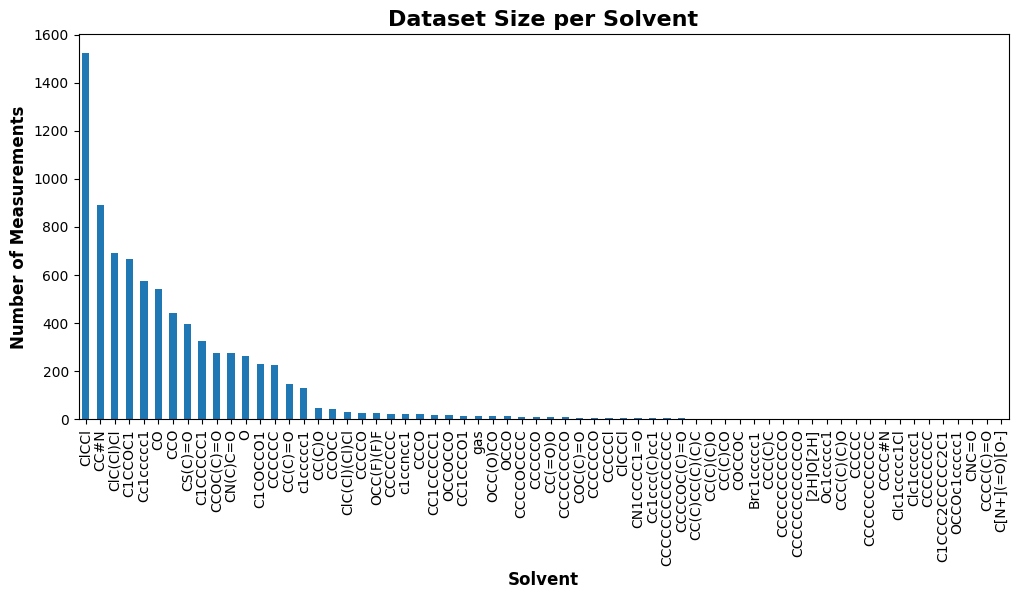

In [6]:
# obtaining frequencies of each solvent within the dataset using a bar chart
solvent_counts = d4c_full['Solvent'].value_counts()

plt.figure(figsize=(12,5))
solvent_counts.plot(kind='bar')
plt.ylabel('Number of Measurements', fontsize=12, weight='bold')
plt.xlabel('Solvent', fontsize=12, weight='bold')
plt.xticks(rotation=90)
plt.title('Dataset Size per Solvent', fontsize=16, weight='bold')
plt.show()

### Comments:

Most frequent solvents are dichloromethane, acetonitrile, chloroform, THF, and toluene, respectively

## Solvent-specific Prediction Errors

In [7]:
# ensuring lengths of test and prediction sets are the same for further analysis
print(len(d4c_test))
print(len(preds))

2062
2062


In [8]:
# creating variable to store valid predictions only - predicted values for both wavelength and log(molar extinction coefficient) target properties
valid = (preds['Predicted Absorption max (nm)'].notna() & preds['Predicted log(e/mol-1 dm3 cm-1)'].notna())

# removing rows with missing predictions/invalid SMILES ("gas")
d4c_test = d4c_test.loc[valid].reset_index(drop=True)
preds = preds.loc[valid].reset_index(drop=True)

# printing number of valid samples remaining in the test subset - will be the same for the ensemble predictions file
print(f'{len(d4c_test)} valid samples remain.')

2059 valid samples remain.


In [9]:
# combining the test subset (inputs and measurements) and ensemble prediction results into one DataFrame
results = d4c_test.copy()
results['Predicted Absorption max (nm)'] = preds['Predicted Absorption max (nm)']
results['Predicted log(e/mol-1 dm3 cm-1)'] = preds['Predicted log(e/mol-1 dm3 cm-1)']

# viewing head of combined DataFrame
results.head()

,Chromophore,Solvent,Absorption max (nm),log(e/mol-1 dm3 cm-1),Predicted Absorption max (nm),Predicted log(e/mol-1 dm3 cm-1)
0,C[Si](C)(C)c1cccc2ccccc12,C1CCCCC1,294.0,3.73,298.173156,3.798348
1,C[SiH](C)c1cccc2ccccc12,C1CCCCC1,294.0,3.75,295.137608,3.804180
2,CC(C)(C)[Si](C)(C)c1cccc2ccccc12,C1CCCCC1,295.0,3.78,302.905436,3.870161
3,CCCCCCCC[Si](C)(C)c1cccc2ccccc12,C1CCCCC1,294.0,3.76,307.459098,3.836281
4,C[Si](C)(C)c1ccc(C#N)c2ccccc12,C1CCCCC1,315.0,3.88,320.726233,3.809440


In [73]:
# creating list to store solvent-specific evaluation metrics
solvent_metrics = []

# iterating through solvents
for solvent, group in results.groupby('Solvent'):

    # grouping true and predicted wavelength values for each solvent into separate variables
    true_wavelength = group['Absorption max (nm)']
    pred_wavelength = group['Predicted Absorption max (nm)']

    # calculating evaluation metrics for wavelength predictions by each solvent type
    wavelength_mae = mean_absolute_error(true_wavelength, pred_wavelength)
    wavelength_rmse = np.sqrt(mean_squared_error(true_wavelength, pred_wavelength))

    # grouping true and predicted log(molar extinction coefficient) values for each solvent into separate variables
    true_log_mec = group['log(e/mol-1 dm3 cm-1)']
    pred_log_mec = group['Predicted log(e/mol-1 dm3 cm-1)']

    # calculating evaluation metrics for log(molar extinction coefficient) predictions by each solvent type
    log_mec_mae = mean_absolute_error(true_log_mec, pred_log_mec)
    log_mec_rmse = np.sqrt(mean_squared_error(true_log_mec, pred_log_mec))

    # updating solvent metrics list to include solvent-specific measurement counts and calculated error metrics for both target properties
    solvent_metrics.append({
        'Solvent': solvent,
        'N': len(group),
        'Absorption max (nm) MAE': wavelength_mae,
        'Absorption max (nm) RMSE': wavelength_rmse,
        'log(e/mol-1 dm3 cm-1) MAE': log_mec_mae,
        'log(e/mol-1 dm3 cm-1) RMSE': log_mec_rmse})

# transforming list containing all relevant solvent metrics into a DataFrame, sorted by their frequency in the test dataset
metrics = (pd.DataFrame(solvent_metrics).sort_values('N', ascending=False))

# viewing first few entries of the solvent metrics DataFrame 
print(metrics.head())

# saving solvent-specific results to a CSV file
metrics.to_csv('solvent_specific_metrics.csv', index=False)

      Solvent    N  Absorption max (nm) MAE  Absorption max (nm) RMSE  \
36      ClCCl  423                18.340079                 27.381088   
4        CC#N  237                18.062902                 27.704758   
35  ClC(Cl)Cl  174                20.885590                 30.293844   
2     C1CCOC1  167                20.308640                 32.339514   
29         CO  143                16.773544                 24.662789   

    log(e/mol-1 dm3 cm-1) MAE  log(e/mol-1 dm3 cm-1) RMSE  
36                   0.175254                    0.279608  
4                    0.176486                    0.284392  
35                   0.128998                    0.201446  
2                    0.177521                    0.256822  
29                   0.223436                    0.348800  


In [11]:
# investigating solvents with largest wavelength prediction RMSE
print('\nHighest Absorption max (nm) RMSE:')
print(metrics.nlargest(10, 'Absorption max (nm) RMSE')[['Solvent', 'N', 'Absorption max (nm) RMSE']])

# investigating solvents with largest log(molar extinction coefficient) prediction RMSE
print('\nHighest log(e/mol-1 dm3 cm-1) RMSE:')
print(metrics.nlargest(10, 'log(e/mol-1 dm3 cm-1) RMSE')[['Solvent', 'N', 'log(e/mol-1 dm3 cm-1) RMSE']])


Highest Absorption max (nm) RMSE:
          Solvent    N  Absorption max (nm) RMSE
14        CCCCCCC    6                 80.020597
16  CCCCCCCCCCCCO    1                 58.965481
17    CCCCCCCCCCO    1                 57.627807
5         CC(=O)O    3                 50.830662
34  ClC(Cl)(Cl)Cl   10                 45.697089
18      CCCCCCCCO    4                 45.255968
31        CS(C)=O  102                 44.247211
19        CCCCCCO    2                 42.206120
22          CCCCO    5                 35.984758
0      Brc1ccccc1    2                 35.433308

Highest log(e/mol-1 dm3 cm-1) RMSE:
          Solvent   N  log(e/mol-1 dm3 cm-1) RMSE
16  CCCCCCCCCCCCO   1                    1.138790
17    CCCCCCCCCCO   1                    1.106142
5         CC(=O)O   3                    0.917139
19        CCCCCCO   2                    0.845934
6       CC(C)(C)O   1                    0.575050
18      CCCCCCCCO   4                    0.570247
11     CCC(C)(C)O   1                  

In [12]:
# investigating solvents with largest wavelength prediction MAE
print("\nHighest Absorption max (nm) MAE:")
print(metrics.nlargest(10, "Absorption max (nm) MAE")[["Solvent", "N", "Absorption max (nm) MAE"]])

# investigating solvents with largest log(molar extinction coefficient) prediction MAE
print("\nHighest log(e/mol-1 dm3 cm-1) MAE:")
print(metrics.nlargest(10, 'log(e/mol-1 dm3 cm-1) MAE')[["Solvent", "N", "log(e/mol-1 dm3 cm-1) MAE"]])


Highest Absorption max (nm) MAE:
          Solvent   N  Absorption max (nm) MAE
16  CCCCCCCCCCCCO   1                58.965481
17    CCCCCCCCCCO   1                57.627807
14        CCCCCCC   6                55.048959
18      CCCCCCCCO   4                44.339812
0      Brc1ccccc1   2                35.201434
5         CC(=O)O   3                33.539453
19        CCCCCCO   2                31.525148
34  ClC(Cl)(Cl)Cl  10                30.262110
22          CCCCO   5                30.107296
24           CCCO   2                30.070317

Highest log(e/mol-1 dm3 cm-1) MAE:
          Solvent  N  log(e/mol-1 dm3 cm-1) MAE
16  CCCCCCCCCCCCO  1                   1.138790
17    CCCCCCCCCCO  1                   1.106142
19        CCCCCCO  2                   0.804430
6       CC(C)(C)O  1                   0.575050
11     CCC(C)(C)O  1                   0.570067
5         CC(=O)O  3                   0.547628
14        CCCCCCC  6                   0.426466
18      CCCCCCCCO  4         

### Comments: 

Many solvents within the dataset have <100 measurements - error metrics obtained for these are not as reliable as those obtained for the top solvents in the dataset

Most large error metrics attributed to rarer solvents within the dataset

## Target Residuals by Solvent

In [15]:
# calculating target residuals and adding to combined DataFrame
results['Absorption max (nm) Error'] = (results['Predicted Absorption max (nm)'] - results['Absorption max (nm)'])
results['Log(e/mol-1 dm3 cm-1) Error'] = (results['Predicted log(e/mol-1 dm3 cm-1)'] - results['log(e/mol-1 dm3 cm-1)'])

# viewing head of DataFrame including error values
results.head()

,Chromophore,Solvent,Absorption max (nm),log(e/mol-1 dm3 cm-1),Predicted Absorption max (nm),Predicted log(e/mol-1 dm3 cm-1),Absorption max (nm) Error,Log(e/mol-1 dm3 cm-1) Error
0,C[Si](C)(C)c1cccc2ccccc12,C1CCCCC1,294.0,3.73,298.173156,3.798348,4.173156,0.068348
1,C[SiH](C)c1cccc2ccccc12,C1CCCCC1,294.0,3.75,295.137608,3.804180,1.137608,0.054180
2,CC(C)(C)[Si](C)(C)c1cccc2ccccc12,C1CCCCC1,295.0,3.78,302.905436,3.870161,7.905436,0.090161
3,CCCCCCCC[Si](C)(C)c1cccc2ccccc12,C1CCCCC1,294.0,3.76,307.459098,3.836281,13.459098,0.076281
4,C[Si](C)(C)c1ccc(C#N)c2ccccc12,C1CCCCC1,315.0,3.88,320.726233,3.809440,5.726233,-0.070560


In [16]:
# calculating wavelength and log(molar extinction coefficient) residuals by solvent, repectively
wavelength_residuals = (results.groupby('Solvent')['Absorption max (nm) Error'].agg(['mean', 'std', 'count']).sort_values('mean'))
log_mec_residuals = (results.groupby('Solvent')['Log(e/mol-1 dm3 cm-1) Error'].agg(['mean', 'std', 'count']).sort_values('mean'))

# viewing wavelength residual statistics
wavelength_residuals

,mean,std,count
Solvent,,,
CCCO,-30.070317,25.512091,2
CC(=O)O,-24.671302,54.429997,3
COC(C)=O,-18.471255,NaN,1
CCCCCCC,-17.291455,85.587160,6
CCCCO,-16.218159,35.914380,5
CC(C)=O,-9.200454,26.607722,30
[2H]O[2H],-7.844578,NaN,1
C1CCOC1,-5.426606,31.976851,167
CN(C)C=O,-4.791408,29.451639,70


In [17]:
# viewing log(molar extinction coefficient) residual statistics
log_mec_residuals

,mean,std,count
Solvent,,,
CCCCCCCCCCCCO,-1.138790,NaN,1
CCCCCCCCCCO,-1.106142,NaN,1
CCCCCCO,-0.804430,0.370129,2
CC(C)(C)O,-0.575050,NaN,1
CCC(C)(C)O,-0.570067,NaN,1
CC(=O)O,-0.547628,0.901038,3
CCCCCCCCO,-0.376059,0.494991,4
CCCC#N,-0.217236,NaN,1
CCCCO,-0.190060,0.343412,5


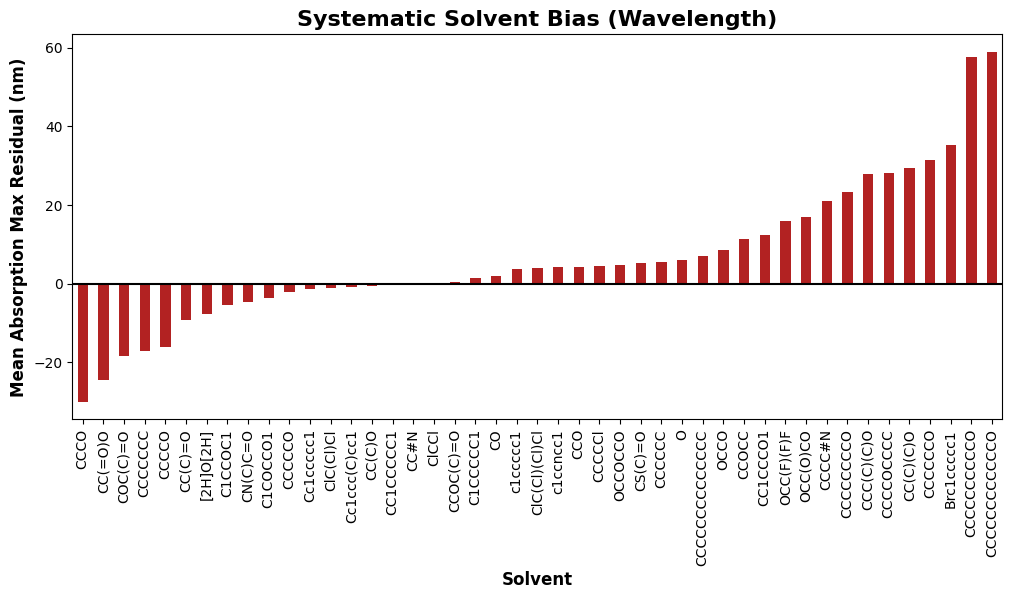

In [99]:
# creating bar chart to visualise solvent bias by mean wavelength residuals
plt.figure(figsize=(12,5))
wavelength_residuals['mean'].plot(kind='bar', color='firebrick')
# adding horizontal line through y=0 to easily visualise positive and negative residuals for each solvent
plt.axhline(0, color='black')
plt.xlabel('Solvent', fontsize=12, weight='bold')
plt.ylabel('Mean Absorption Max Residual (nm)', fontsize=12, weight='bold')
plt.title('Systematic Solvent Bias (Wavelength)', fontsize=16, weight='bold')
plt.show()

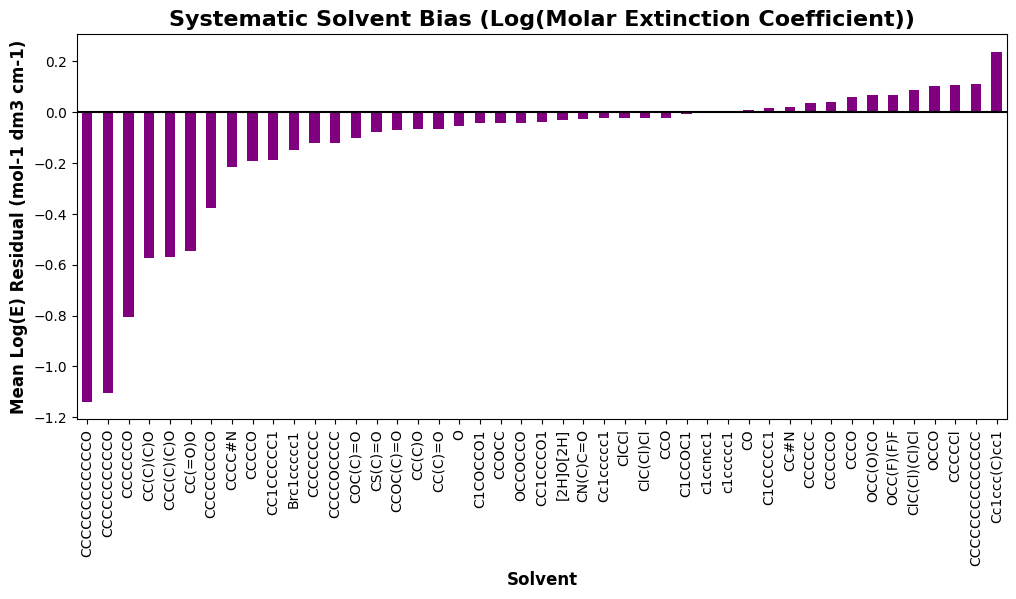

In [100]:
# creating bar chart to visualise solvent bias by mean log(molar extinction coefficient) residuals
plt.figure(figsize=(12,5))
log_mec_residuals['mean'].plot(kind='bar', color='purple')
# adding horizontal line through y=0 to easily visualise positive and negative residuals for each solvent
plt.axhline(0, color='black')
plt.xlabel('Solvent', fontsize=12, weight='bold')
plt.ylabel('Mean Log(E) Residual (mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.title('Systematic Solvent Bias (Log(Molar Extinction Coefficient))', fontsize=16, weight='bold')
plt.show()

### Comments:

Wavelength predictions tend to be higher than they actually are, and logE predictions tend to be lower than they actually are

Same as before - the largest residuals are often attributed to very rare solvents within the dataset, some having as little as 1 measurement

Average residuals obtained for the most frequent solvents close to 0 - implies model is able to learn genuine solvent effects during predictions with sufficient measurements available in the data

## Correlation Between Solvent Frequency and Model Performance

In [86]:
# specifying variables (target-specific error metrics) to compare
error_metrics = ['Absorption max (nm) MAE', 'Absorption max (nm) RMSE', 'log(e/mol-1 dm3 cm-1) MAE', 'log(e/mol-1 dm3 cm-1) RMSE']

# initialising a loop to calculate Pearson and Spearman correlations for each target-specific error metric to investigate the relationship between
# solvent frequency and Deep4Chem-trained Chemprop performance - also including p-values to investigate whether results obtained indicate a significant
# relationship between both or not
for metric in error_metrics:
    pearson_r, pearson_p = pearsonr(metrics['N'], metrics[metric])
    spearman_rho, spearman_p = spearmanr(metrics['N'], metrics[metric])
    # printing results obtained for each evaluation metric
    print(f'\n{metric}:')
    print(f'Pearson r = {pearson_r:.3f} (p = {pearson_p:.4f})')
    print(f'Spearman ρ = {spearman_rho:.3f} (p = {spearman_p:.4f})')


Absorption max (nm) MAE:
Pearson r = -0.139 (p = 0.3626)
Spearman ρ = 0.018 (p = 0.9063)

Absorption max (nm) RMSE:
Pearson r = 0.022 (p = 0.8868)
Spearman ρ = 0.246 (p = 0.1038)

log(e/mol-1 dm3 cm-1) MAE:
Pearson r = -0.170 (p = 0.2650)
Spearman ρ = 0.086 (p = 0.5751)

log(e/mol-1 dm3 cm-1) RMSE:
Pearson r = -0.090 (p = 0.5560)
Spearman ρ = 0.224 (p = 0.1399)


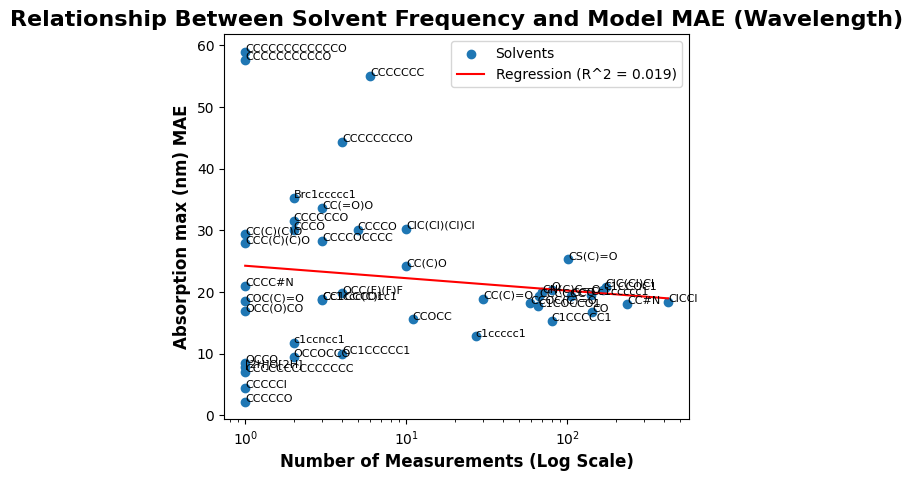

In [87]:
# creating a scatter plot to investigate the relationship between solvent frequency and wavelength MAE
plt.figure(figsize=(6,5))
plt.scatter(metrics['N'], metrics['Absorption max (nm) MAE'], label='Solvents')

# iterating through each row of the dataset and adding the corresponding solvent name next to each plotted point
for _, row in metrics.iterrows():
    plt.text(row['N'], row['Absorption max (nm) MAE'], row['Solvent'], fontsize=8)

# defining x- and y-values to perform linear regression on - calculating the logarithm (base 10) of solvent frequencies for simpler visualisation
x = np.log10(metrics['N'])
y = metrics['Absorption max (nm) MAE']

# performing linear regression between specified x- and y-values - returns the regression parameters and statistics for plotting
slope, intercept, r, p, stderr = linregress(x, y)
# calculating the fitted regression line values
y_fit = intercept + slope * x

# overlaying the regression line on the scatter plot and labelling it with the R^2 coefficient
plt.plot(metrics['N'], y_fit, color='red', label=f'Regression (R^2 = {r**2:.3f})')

plt.legend()

# displays the x-axis on a logarithmic scale for simpler visualisation
plt.xscale('log')

# labelling axes and titling plot
plt.xlabel('Number of Measurements (Log Scale)', fontsize=12, weight='bold')
plt.ylabel('Absorption max (nm) MAE', fontsize=12, weight='bold')
plt.title('Relationship Between Solvent Frequency and Model MAE (Wavelength)', fontsize=16, weight='bold')

plt.show()

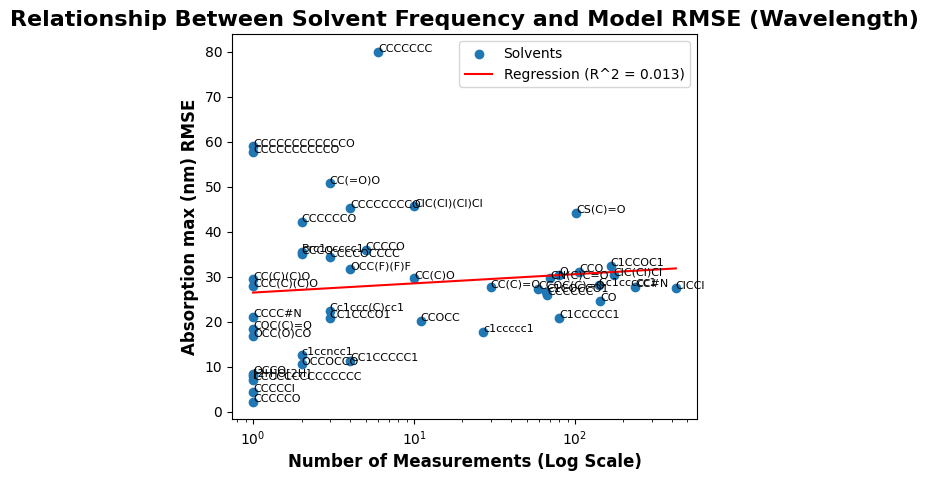

In [89]:
# creating a scatter plot to investigate the relationship between solvent frequency and wavelength MAE
plt.figure(figsize=(6,5))
plt.scatter(metrics['N'], metrics['Absorption max (nm) RMSE'], label='Solvents')

# iterating through each row of the dataset and adding the corresponding solvent name next to each plotted point
for _, row in metrics.iterrows():
    plt.text(row['N'], row['Absorption max (nm) RMSE'], row['Solvent'], fontsize=8)

# defining x- and y-values to perform linear regression on - calculating the logarithm (base 10) of solvent frequencies for simpler visualisation
x = np.log10(metrics['N'])
y = metrics['Absorption max (nm) RMSE']

# performing linear regression between specified x- and y-values - returns the regression parameters and statistics for plotting
slope, intercept, r, p, stderr = linregress(x, y)
# calculating the fitted regression line values
y_fit = intercept + slope * x

# overlaying the regression line on the scatter plot and labelling it with the R^2 coefficient
plt.plot(metrics['N'], y_fit, color='red', label=f'Regression (R^2 = {r**2:.3f})')

plt.legend()

# displays the x-axis on a logarithmic scale for simpler visualisation
plt.xscale('log')

# labelling axes and titling plot
plt.xlabel('Number of Measurements (Log Scale)', fontsize=12, weight='bold')
plt.ylabel('Absorption max (nm) RMSE', fontsize=12, weight='bold')
plt.title('Relationship Between Solvent Frequency and Model RMSE (Wavelength)', fontsize=16, weight='bold')

plt.show()

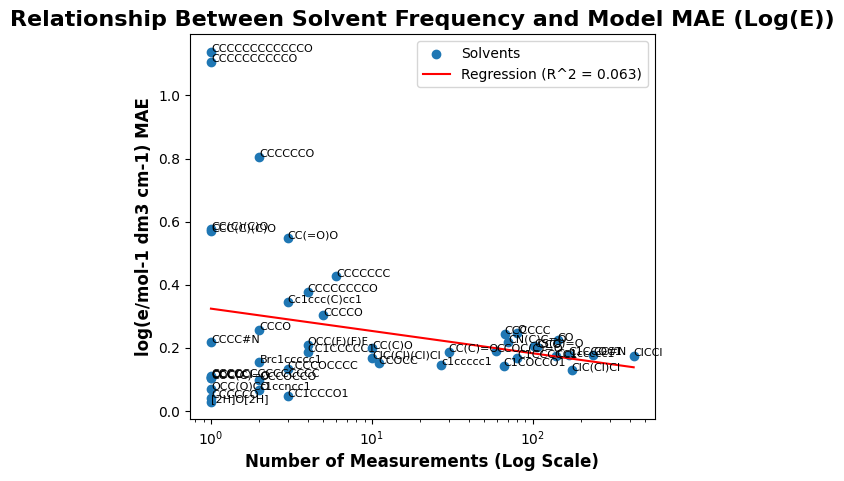

In [90]:
# creating a scatter plot to investigate the relationship between solvent frequency and wavelength MAE
plt.figure(figsize=(6,5))
plt.scatter(metrics['N'], metrics['log(e/mol-1 dm3 cm-1) MAE'], label='Solvents')

# iterating through each row of the dataset and adding the corresponding solvent name next to each plotted point
for _, row in metrics.iterrows():
    plt.text(row['N'], row['log(e/mol-1 dm3 cm-1) MAE'], row['Solvent'], fontsize=8)

# defining x- and y-values to perform linear regression on - calculating the logarithm (base 10) of solvent frequencies for simpler visualisation
x = np.log10(metrics['N'])
y = metrics['log(e/mol-1 dm3 cm-1) MAE']

# performing linear regression between specified x- and y-values - returns the regression parameters and statistics for plotting
slope, intercept, r, p, stderr = linregress(x, y)
# calculating the fitted regression line values
y_fit = intercept + slope * x

# overlaying the regression line on the scatter plot and labelling it with the R^2 coefficient
plt.plot(metrics['N'], y_fit, color='red', label=f'Regression (R^2 = {r**2:.3f})')

plt.legend()

# displays the x-axis on a logarithmic scale for simpler visualisation
plt.xscale('log')

# labelling axes and titling plot
plt.xlabel('Number of Measurements (Log Scale)', fontsize=12, weight='bold')
plt.ylabel('log(e/mol-1 dm3 cm-1) MAE', fontsize=12, weight='bold')
plt.title('Relationship Between Solvent Frequency and Model MAE (Log(E))', fontsize=16, weight='bold')

plt.show()

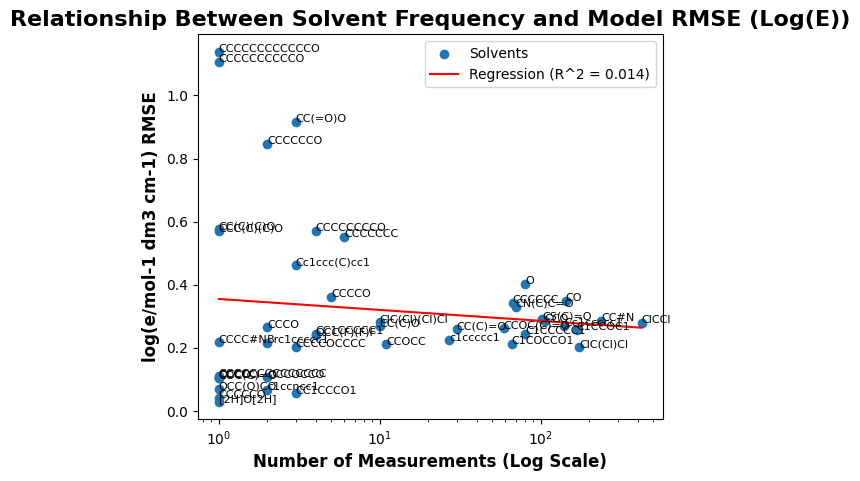

In [91]:
# creating a scatter plot to investigate the relationship between solvent frequency and wavelength MAE
plt.figure(figsize=(6,5))
plt.scatter(metrics['N'], metrics['log(e/mol-1 dm3 cm-1) RMSE'], label='Solvents')

# iterating through each row of the dataset and adding the corresponding solvent name next to each plotted point
for _, row in metrics.iterrows():
    plt.text(row['N'], row['log(e/mol-1 dm3 cm-1) RMSE'], row['Solvent'], fontsize=8)

# defining x- and y-values to perform linear regression on - calculating the logarithm (base 10) of solvent frequencies for simpler visualisation
x = np.log10(metrics['N'])
y = metrics['log(e/mol-1 dm3 cm-1) RMSE']

# performing linear regression between specified x- and y-values - returns the regression parameters and statistics for plotting
slope, intercept, r, p, stderr = linregress(x, y)
# calculating the fitted regression line values
y_fit = intercept + slope * x

# overlaying the regression line on the scatter plot and labelling it with the R^2 coefficient
plt.plot(metrics['N'], y_fit, color='red', label=f'Regression (R^2 = {r**2:.3f})')

plt.legend()

# displays the x-axis on a logarithmic scale for simpler visualisation
plt.xscale('log')

# labelling axes and titling plot
plt.xlabel('Number of Measurements (Log Scale)', fontsize=12, weight='bold')
plt.ylabel('log(e/mol-1 dm3 cm-1) RMSE', fontsize=12, weight='bold')
plt.title('Relationship Between Solvent Frequency and Model RMSE (Log(E))', fontsize=16, weight='bold')

plt.show()

### Comments:

Correlation values all indicate no linear correlation or relationship between solevnt frequency and model performance - slight positive Spearman correlations for RMSE suggest a weak trend of increased error with solvent frequency, however these are not particularly significant

All p-values are above 0.05 => no observed correlations are statistically significant

Random variation over RMSE/MAE ranges for both target properites appears to even out as frequency of solvents becomes larger, so a systematic increase in error due to the presence of rare solvents does not seem to be the case with this dataset and model

Model prediction seems to be generally independent of solvent frequency, suggesting Chemprop generalises sufficiently across solvents and is able to learn chemically- and physically- meaningful information from those inputs rather than random guessing or reliance on the most frequent solvents within the Deep4Chem dataset